# Non-linear systems in 2D

### Example: 

Consider the system of nonlinear differential equations:
$$
\dot{x} = x + e^{-y}
$$

$$
\dot{y} = -y
$$

1. Use **qualitative arguments** to obtain information about the phase portrait (i.e., find equilibrium points, nullclines, and classify the stability).

2. Using a computer (via Python code), plot the **vector field**.

3. Use the **Runge-Kutta method** to compute several trajectories and plot them on the phase plane.

### 1. Use qualitative arguments to obtain information about the phase portrait (i.e., find equilibrium points, nullclines, and classify the stability).

### 2. Using a computer (via Python code), plot the direction field.

### Phase Diagram

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc

In [2]:
# Slope function for the derivatives

def ode_system(t, s):
    """
    Inputs: t -> time
            s -> (x,y)
    Return: [dxt, dyt]
    """
    # Get the state
    x, y = s
    
    # Slopes
    dxt = x + np.exp(-y)
    dyt = -y

    return [dxt, dyt]

In [3]:
# Set limits for the axes 
xl, xr = -5., +5.
yl, yr = -5., +5.

# Resolution
nx = ny = 20

# Axes
x_1d = np.linspace(xl, xr, nx)
y_1d = np.linspace(xl, xr, ny)

# Create meshgrid
x_2d, y_2d = np.meshgrid(x_1d, y_1d)

# Add the vector components for the velocities (derivatives)
vx_2d = x_2d + np.exp(-y_2d)
vy_2d = -y_2d

# Velocity Magnitude 
v_mag = np.sqrt(vx_2d**2 + vy_2d**2)

# Normalise
vx_2d = vx_2d / v_mag 
vy_2d = vy_2d / v_mag 

# Fixed point
x0, y0 = (-1., 0.)


# Nullclines
y_null = 0.

x_null = -np.exp(-y_1d)

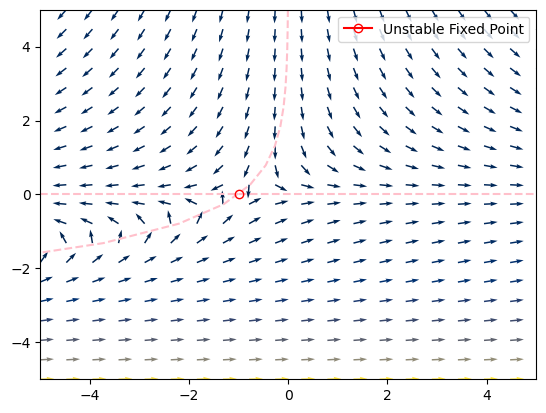

In [9]:
# Phase diagram
plt.figure()

plt.axhline(y_null, color = "pink", linestyle = "--")

plt.plot(x_null, y_1d, color = "pink", linestyle = "--")

plt.plot(x0, y0, marker = "o", color = "red", fillstyle = "none", label = "Unstable Fixed Point")
plt.quiver(x_2d, y_2d, vx_2d, vy_2d, v_mag, cmap = "cividis")

plt.xlim(xl, xr)
plt.ylim(yl, yr)

plt.legend()
plt.show()


### 3. Use the Runge-Kutta method to compute several trajectories and plot them on the phase plane.

In [29]:
# Integrator -> SciPy

def compute_traj(ics_input):
    """
    """
    # Get ICs
    x0, y0 = ics_input

    # Forward in time integrator
    sln_f = sc.integrate.solve_ivp(ode_system, t_limits, [x0, y0], t_eval = t_axis, method = "RK45")

    # Backward in time integrator
    sln_b = sc.integrate.solve_ivp(ode_system, t_backli, [x0, y0], t_eval = -t_axis, method = "RK45")
    
    return sln_f.y[0], sln_f.y[1], sln_b.y[0], sln_b.y[1]

In [30]:
# Time discretisation
t_limits = [0., 5.]
t_backli = [0., -5.]

# Number of time steps
n_t = 100

# Time axis
t_axis = np.linspace(t_limits[0], t_limits[1], n_t)


In [32]:
# Initial conditions
ics = [[-3., 2.], [0.,-3.]]

# Empty list 
slns_f = []
slns_b = []

# For loop to integrate all trajectories
# Integrate for ics
for ic in ics:
    x_t, y_t, x_nt, y_nt  = compute_traj(ic)
    slns_f.append([x_t, y_t])
    slns_b.append([x_nt, y_nt])

print(len(slns_f), len(slns_b))



2 2


0
1


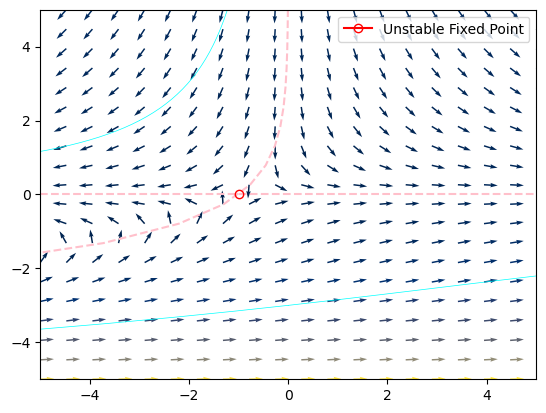

In [34]:
# Phase diagram
plt.figure()

plt.axhline(y_null, color = "pink", linestyle = "--")

plt.plot(x_null, y_1d, color = "pink", linestyle = "--")

plt.plot(x0, y0, marker = "o", color = "red", fillstyle = "none", label = "Unstable Fixed Point")
plt.quiver(x_2d, y_2d, vx_2d, vy_2d, v_mag, cmap = "cividis")

# Add the trajectories
for j in range(len(slns)):
    print(j)
    plt.plot(slns_f[j][0], slns_f[j][1], color = "cyan", linestyle = "-", linewidth = 0.5)
    plt.plot(slns_b[j][0], slns_b[j][1], color = "cyan", linestyle = "-", linewidth = 0.5)

plt.xlim(xl, xr)
plt.ylim(yl, yr)

plt.legend()
plt.show()
